Importing Libraries

In [253]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import sklearn
from sklearn.experimental import enable_iterative_imputer  
from sklearn.linear_model import BayesianRidge
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn import metrics
import pyreadstat
import seaborn as sns
import scipy.stats as stats
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant as ac 
import random
import warnings
warnings.filterwarnings('ignore')

Load Data

In [254]:
df, meta = pyreadstat.read_sav('data.sav')
df.head()

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,526301100.0,20.0,RL,141.0,31770.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,NA,0.0,5.0,2010.0,WD,Normal,215000.0
1,2.0,526350040.0,20.0,RH,80.0,11622.0,Pave,NA,Reg,Lvl,...,0.0,NA,MnPrv,NA,0.0,6.0,2010.0,WD,Normal,105000.0
2,3.0,526351010.0,20.0,RL,81.0,14267.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,Gar2,12500.0,6.0,2010.0,WD,Normal,172000.0
3,4.0,526353030.0,20.0,RL,93.0,11160.0,Pave,NA,Reg,Lvl,...,0.0,NA,NA,NA,0.0,4.0,2010.0,WD,Normal,244000.0
4,5.0,527105010.0,60.0,RL,74.0,13830.0,Pave,NA,IR1,Lvl,...,0.0,NA,MnPrv,NA,0.0,3.0,2010.0,WD,Normal,189900.0


Data Label

In [255]:
for col, label in meta.column_names_to_labels.items():
    print(f"{col}: {label}")

Order: Observation number/ID.
PID: Parcel identification number (used for city web site review).
MSSubClass: Type of dwelling involved in the sale (a coded category).
MSZoning: General zoning classification of the sale.
LotFrontage: Linear feet of street connected to property.
LotArea: Lot size in square feet.
Street: Type of road access to property (e.g., Paved, Gravel).
Alley: Type of alley access to property.
LotShape: General shape of property (e.g., Regular, Irregular).
LandContour: Flatness of the property.
Utilities: Type of utilities available.
LotConfig: Lot configuration (e.g., Corner, Inside).
LandSlope: Slope of property (e.g., Gentle, Moderate, Severe).
Neighborhood: Physical locations within Ames city limits.
Condition1: Proximity to main road or railroad.
Condition2: Proximity to a second main road or railroad (if present).
BldgType: Type of dwelling (e.g., Single-family, Duplex).
HouseStyle: Style of dwelling (e.g., 1Story, 2Story, Split Level).
OverallQual: Overall mat

Null Count

In [256]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

LotFrontage     490
MasVnrArea       23
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageYrBlt     159
GarageCars        1
GarageArea        1
dtype: int64


Variables' unique value

In [257]:
unique_values = {col:df[col].unique() 
                 for col in df.select_dtypes(include=['object', 'category']).columns}

for col, values in unique_values.items():
    print(f"Variable: {col}")
    print(f"Values:   {values}")
    print("-" * 30)

Variable: MSZoning
Values:   ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']
------------------------------
Variable: Street
Values:   ['Pave' 'Grvl']
------------------------------
Variable: Alley
Values:   ['NA' 'Pave' 'Grvl']
------------------------------
Variable: LotShape
Values:   ['IR1' 'Reg' 'IR2' 'IR3']
------------------------------
Variable: LandContour
Values:   ['Lvl' 'HLS' 'Bnk' 'Low']
------------------------------
Variable: Utilities
Values:   ['AllPub' 'NoSewr' 'NoSeWa']
------------------------------
Variable: LotConfig
Values:   ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']
------------------------------
Variable: LandSlope
Values:   ['Gtl' 'Mod' 'Sev']
------------------------------
Variable: Neighborhood
Values:   ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 

number of categorical and numeric data

In [258]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
print(f"Categorical columns detected: {len(cat_cols)}")
print(f"Numerical columns detected: {len(num_cols)}")

Categorical columns detected: 43
Numerical columns detected: 39


ENCODE CATEGORICAL DATA

In [259]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', 
    unknown_value=np.nan
)

df_encoded = df.copy()
if cat_cols:
    df_encoded[cat_cols] = encoder.fit_transform(df[cat_cols])

Mice imputation

In [260]:
mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=10),
    max_iter=10,
    random_state=10,
    verbose=1
)

imputed_array = mice_imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(imputed_array, columns=df.columns)

[IterativeImputer] Completing matrix with shape (2930, 82)
[IterativeImputer] Change: 764.2917403597341, scaled tolerance: 1007100.11 
[IterativeImputer] Early stopping criterion reached.


In [261]:
if cat_cols:
    df_imputed[cat_cols] = encoder.inverse_transform(
        df_imputed[cat_cols].round().astype(int))

null count after the imputation   

In [262]:
null_counts = df_imputed.isnull().sum()
print(null_counts[null_counts > 0])   

Series([], dtype: int64)


VIF

In [263]:
X = df_imputed.select_dtypes(include=['number'])
X_with_const = ac(X)     

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) 
                 for i in range(len(X_with_const.columns))]

vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

Global VIF Results for numerical features:
          feature           VIF
17   LowQualFinSF           inf
18      GrLivArea           inf
15      @1stFlrSF           inf
16      @2ndFlrSF           inf
11     BsmtFinSF1  5.586814e+04
14    TotalBsmtSF  5.226081e+04
13      BsmtUnfSF  5.198893e+04
12     BsmtFinSF2  7.704249e+03
1           Order  7.930460e+01
38         YrSold  7.724025e+01
39      SalePrice  6.118867e+00
8       YearBuilt  5.864018e+00
29     GarageArea  5.839543e+00
28     GarageCars  5.828526e+00
27    GarageYrBlt  4.624231e+00
25   TotRmsAbvGrd  4.465149e+00
2             PID  3.776358e+00
6     OverallQual  3.773019e+00
21       FullBath  2.813025e+00
9    YearRemodAdd  2.450877e+00
23   BedroomAbvGr  2.395629e+00
22       HalfBath  2.179785e+00
19   BsmtFullBath  2.162602e+00
4     LotFrontage  1.857150e+00
3      MSSubClass  1.726864e+00
24   KitchenAbvGr  1.580021e+00
26     Fireplaces  1.568200e+00
7     OverallCond  1.543243e+00
10     MasVnrArea  1.476725e+

In [264]:
grliv_sum_array = df_imputed['@1stFlrSF'] + df_imputed['@2ndFlrSF'] + df_imputed['LowQualFinSF']
grliv_difference = df_imputed['GrLivArea'] - grliv_sum_array

bsmt_sum_array = df_imputed['BsmtFinSF1'] + df_imputed['BsmtFinSF2'] + df_imputed['BsmtUnfSF']
bsmt_difference = df_imputed['TotalBsmtSF'] - bsmt_sum_array

print(grliv_difference)
print(bsmt_difference)

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2925    0.0
2926    0.0
2927    0.0
2928    0.0
2929    0.0
Length: 2930, dtype: float64
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2925    0.0
2926    0.0
2927    0.0
2928    0.0
2929    0.0
Length: 2930, dtype: float64


As TotalBsmtSF is sum of BsmtFinSF1, BsmtFinSF2, BsmtUnfSF
and GrLivArea is sum of @1stFlrSF, @2ndFlrSF, LowQualFinSF.


we keep these two variable from the model and drop the sums

In [265]:
cols_to_drop = [ 'Order', 'PID','BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '@1stFlrSF', '@2ndFlrSF', 'LowQualFinSF']
df_reduced = df_imputed.drop(columns=cols_to_drop)

df_numeric_ready = pd.get_dummies(df_reduced, drop_first=True)

df_refined = df_numeric_ready.copy()

VIF After the dropping the variable

In [266]:
X = df_refined.select_dtypes(include=['number'])
X_with_const = ac(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) for i in range(len(X_with_const.columns))]
vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

Global VIF Results for numerical features:
          feature       VIF
10      GrLivArea  7.273631
31      SalePrice  5.988381
21     GarageArea  5.797895
20     GarageCars  5.773236
6       YearBuilt  5.599764
19    GarageYrBlt  4.586952
17   TotRmsAbvGrd  4.422463
4     OverallQual  3.665602
13       FullBath  2.756803
9     TotalBsmtSF  2.393239
7    YearRemodAdd  2.392506
15   BedroomAbvGr  2.312557
2     LotFrontage  1.830202
14       HalfBath  1.811090
1      MSSubClass  1.655799
18     Fireplaces  1.533239
5     OverallCond  1.522838
16   KitchenAbvGr  1.494005
8      MasVnrArea  1.445323
11   BsmtFullBath  1.368733
3         LotArea  1.345779
24  EnclosedPorch  1.235403
22     WoodDeckSF  1.223441
23    OpenPorchSF  1.222631
26    ScreenPorch  1.090453
27       PoolArea  1.090362
12   BsmtHalfBath  1.084793
28        MiscVal  1.062496
30         YrSold  1.046180
29         MoSold  1.040304
25     @3SsnPorch  1.017537


Variance Check

In [267]:
variances = df_refined.var()
variance_df = pd.DataFrame(variances, columns=['Variance'])
variance_df = variance_df.sort_values(by='Variance', ascending=True)

print("--- Variables with the Lowest Variance ---")
print(variance_df.head(20))

threshold = 0.001
low_variance_cols = variance_df[variance_df['Variance'] < threshold].index.tolist()

print(f"\nColumns with variance below {threshold}:")
print(low_variance_cols)

--- Variables with the Lowest Variance ---
                      Variance
RoofMatl_Roll         0.000341
Neighborhood_Landmrk  0.000341
Condition2_RRAn       0.000341
Exterior2nd_Other     0.000341
MiscFeature_TenC      0.000341
SaleType_VWD          0.000341
Condition2_RRAe       0.000341
Utilities_NoSeWa      0.000341
Electrical_Mix        0.000341
RoofMatl_Metal        0.000341
Exterior1st_ImStucc   0.000341
Exterior1st_PreCast   0.000341
Exterior2nd_PreCast   0.000341
MasVnrType_CBlock     0.000341
RoofMatl_Membran      0.000341
KitchenQual_Po        0.000341
Condition2_RRNn       0.000682
PoolQC_Fa             0.000682
Heating_OthW          0.000682
Neighborhood_GrnHill  0.000682

Columns with variance below 0.001:
['RoofMatl_Roll', 'Neighborhood_Landmrk', 'Condition2_RRAn', 'Exterior2nd_Other', 'MiscFeature_TenC', 'SaleType_VWD', 'Condition2_RRAe', 'Utilities_NoSeWa', 'Electrical_Mix', 'RoofMatl_Metal', 'Exterior1st_ImStucc', 'Exterior1st_PreCast', 'Exterior2nd_PreCast', 'MasVnrT

Correaltion Check

In [268]:
vars_to_check = [col for col in df_refined if col not in cols_to_drop]

specific_correlations = df_refined[vars_to_check].corr()[['SalePrice']]

correlations_threshold = 0.001
low_corr_cols = specific_correlations[abs(specific_correlations['SalePrice']) < correlations_threshold]

print("Correlation with SalePrice:")
print(specific_correlations.drop('SalePrice'))
print(f"\nColumns with low correlation to SalePrice (Abs Corr < {correlations_threshold}):")
print(low_corr_cols)

Correlation with SalePrice:
                       SalePrice
MSSubClass             -0.085092
LotFrontage             0.351349
LotArea                 0.266549
OverallQual             0.799262
OverallCond            -0.101697
...                          ...
SaleCondition_AdjLand  -0.057710
SaleCondition_Alloca   -0.021564
SaleCondition_Family   -0.036853
SaleCondition_Normal   -0.141418
SaleCondition_Partial   0.350122

[279 rows x 1 columns]

Columns with low correlation to SalePrice (Abs Corr < 0.001):
                 SalePrice
RoofMatl_Metal   -0.000184
Foundation_Wood   0.000054
SaleType_ConLI   -0.000480


In [269]:
cols_to_remove = set(low_variance_cols) | set(low_corr_cols.index)
print(f"\nTotal columns to remove (low variance or low correlation): {len(cols_to_remove)}")


Total columns to remove (low variance or low correlation): 30


In [270]:
df_cleaned = df_refined.drop(columns=cols_to_remove)

Dealing with outliers

Creator of the AMES housing data set Dean De Cock suggests to drop observation of gross living area > 4000

In [271]:
df_cleaned2 = df_cleaned.copy()
df_cleaned2 = df_cleaned2[df_cleaned2['GrLivArea'] <= 4000]
print(len(df_cleaned[df_cleaned['GrLivArea'] > 4000]))

5


function for graph

In [272]:
def plot_regression_diagnostics(model, y_true, y_pred, X_scaled):
    residuals = y_true - y_pred
    
    n = len(y_true)
    p = model.coef_.shape[0] + 1 
    mse = np.mean(residuals**2)
    leverage = (1/n) + (X_scaled**2).sum(axis=1) / ((X_scaled**2).sum())
    cooks_d = (residuals**2 / (p * mse)) * (leverage / (1 - leverage)**2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    plt.subplots_adjust(hspace=0.3)

    sns.regplot(x=y_true, y=y_pred, ax=axes[0, 0], 
                scatter_kws={'alpha':0.5}, 
                line_kws={'color':'red'})
    
    axes[0, 0].set_title('Predicted vs. Actual Sales Price')
    axes[0, 0].set_xlabel('Actual Price')
    axes[0, 0].set_ylabel('Predicted Price')

    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q Plot')

    sns.residplot(x=y_pred, y=residuals, 
                  lowess=True, 
                  ax=axes[1, 0], 
                  scatter_kws={'alpha':0.5}, 
                  line_kws={'color':'red'})
    
    axes[1, 0].set_title('Residuals vs. Fitted')
    axes[1, 0].set_xlabel('Predicted Sales Price')
    axes[1, 0].set_ylabel('Residuals')
    axes[1, 0].axhline(0, color='black', linestyle='--')

    axes[1, 1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
    axes[1, 1].set_title("Cook's Distance")
    axes[1, 1].set_xlabel('Observation Index')
    axes[1, 1].set_ylabel('Distance')
    axes[1, 1].axhline(4/n, color='red', linestyle='--', label='Threshold (4/n)')
    axes[1, 1].legend()

    plt.show()

In [273]:
scaler = StandardScaler()

In [274]:
y = df_cleaned2['SalePrice']
X = df_cleaned2.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [275]:
X_train = X_train.astype(float)
full_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

In [276]:
mse_full_model = full_model.mse_resid
print(f"Full Model MSE: {mse_full_model:.4f}")

Full Model MSE: 423327215.9551


function for train rmse r2 adj r2 rss press cp

In [277]:
def model_diagnostics(model, X_scaled, y_true, y_pred_org, full_model_mse = mse_full_model):
    n = len(y_true)
    p = np.count_nonzero(model.coef_) + (1 if model.intercept_ != 0 else 0)
    
    mse = metrics.mean_squared_error(y_true, y_pred_org)
    rss = np.sum((y_true - y_pred_org) ** 2)
    r2 = r2_score(y_true, y_pred_org)
    
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p)
    
    aic = n * np.log(mse) + 2 * p
    bic = n * np.log(mse) + p * np.log(n)
    
    sigma_est = full_model_mse if full_model_mse else (rss / (n - p))
    cp = (rss / sigma_est) - (n - 2 * p)

    print(f"Model Diagnostics:")
    print(f"RMSE: {np.sqrt(mse):.4f}")
    print(f"R²: {r2:.4f} | Adj R²: {adj_r2:.4f}")
    print(f"AIC: {aic:.4f} | BIC: {bic:.4f}")
    print(f"Mallows' Cp: {cp:.4f}")
    print(f"Parameters (p): {p}")

permorfing elastic net 

box cox transformation on both side

In [278]:
y_bc, lam = boxcox(y_train)
print(f"Optimal Box-Cox Lambda: {lam:.4f}")

Optimal Box-Cox Lambda: -0.0350


In [279]:
pt = PowerTransformer(method='yeo-johnson')
X_train_transformed = pt.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_transformed)

In [280]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_bc)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net.fit(X_train_scaled, y_bc)

Optimal Alpha: 0.02811768697974228
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.02811768697974228), l1_ratio=np.float64(0.1))

In [281]:
y_pred_train = elastic_net.predict(X_train_scaled)
y_pred_train_org = inv_boxcox(y_pred_train, lam)

model_diagnostics(elastic_net, X_train_scaled, y_train, y_pred_train_org)

Model Diagnostics:
RMSE: 19900.4202
R²: 0.9384 | Adj R²: 0.9357
AIC: 40702.4431 | BIC: 41202.9908
Mallows' Cp: 45.9884
Parameters (p): 89


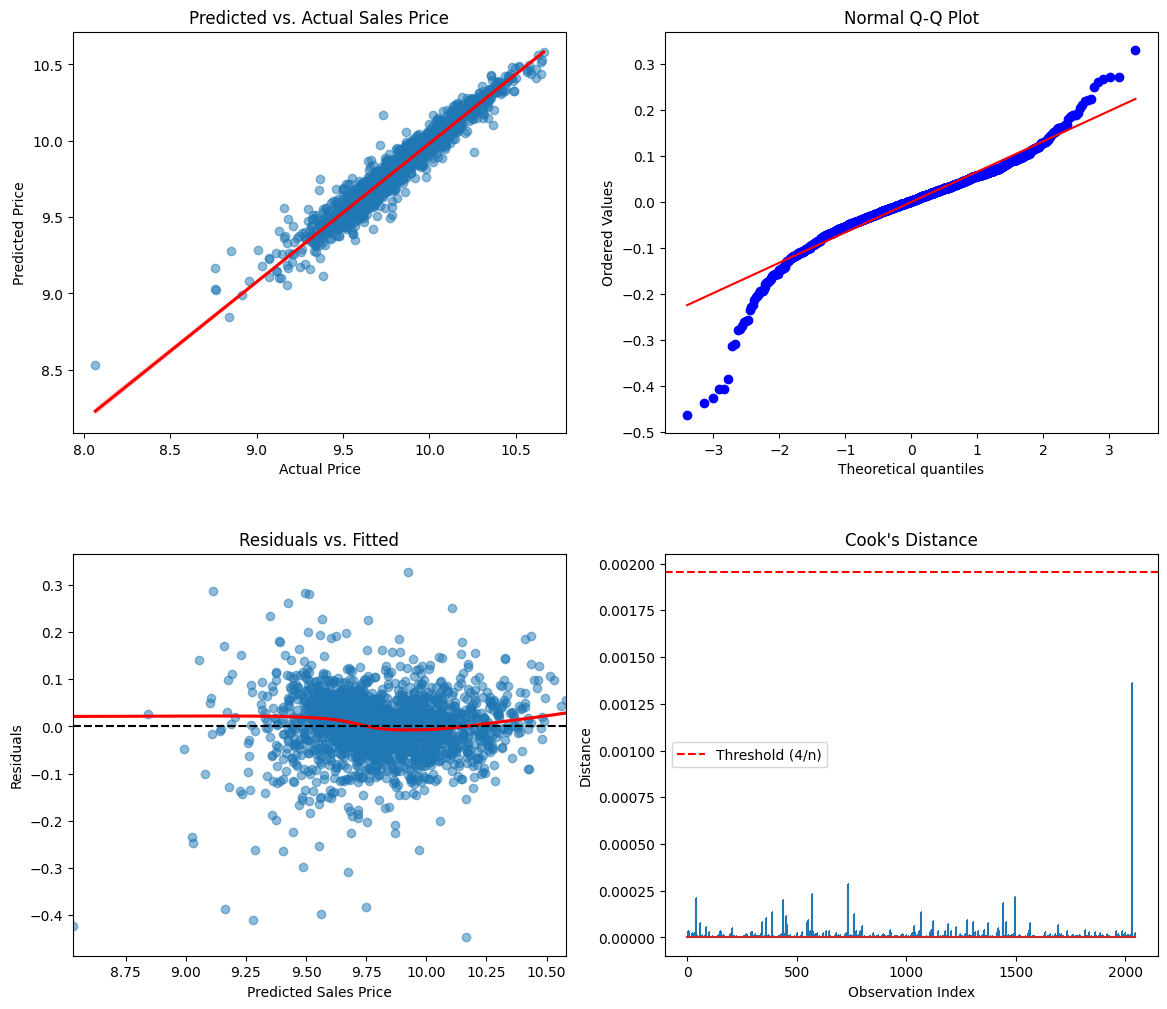

In [282]:
plot_regression_diagnostics(elastic_net, y_bc, y_pred_train, X_train_scaled)

skewness check

In [283]:
skewness_y = stats.skew(y_train)
print(f"Skewness of SalePrice: {skewness_y:.4f}")

Skewness of SalePrice: 1.7056


In [284]:
skewness_x = stats.skew(X_train_scaled, axis=0)
print(f"Skewness of features (first 10): {skewness_x[:10]}")

highly_skewed_features = np.where(abs(skewness_x) > 1)[0]
print(f"Number of highly skewed features: {len(highly_skewed_features)}")

Skewness of features (first 10): [ 7.39783217e-02  1.29643771e-01  7.57016879e-02  2.45686754e-02
  6.99118910e-02 -1.28056884e-01 -2.12986979e-01  4.46996321e-01
 -6.57826252e-02 -2.67308569e-05]
Number of highly skewed features: 204


apply box cox transformation 

log transform in y

In [285]:
y_train_log = np.log1p(y_train)

In [286]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_train_log)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net2 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net2.fit(X_train_scaled, y_train_log)

Optimal Alpha: 0.040949150623804234
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.040949150623804234), l1_ratio=np.float64(0.1))

In [287]:
y_pred_log = elastic_net2.predict(X_train_scaled)
y_pred_original = np.expm1(y_pred_log)

In [288]:
model_diagnostics(elastic_net2, X_train_scaled, y_train, y_pred_original)

Model Diagnostics:
RMSE: 19972.0072
R²: 0.9380 | Adj R²: 0.9350
AIC: 40727.1439 | BIC: 41255.8122
Mallows' Cp: 69.7906
Parameters (p): 94


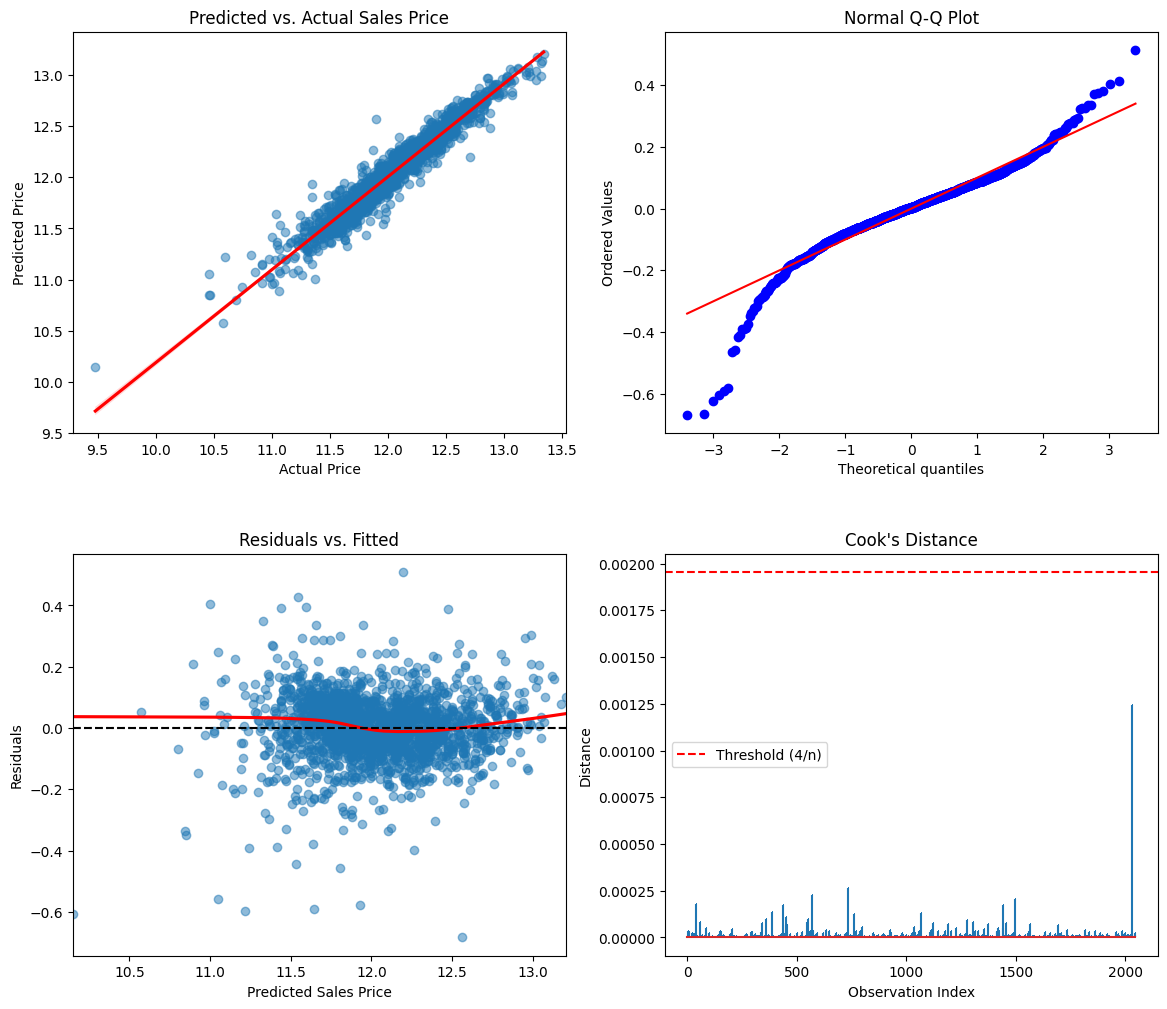

In [289]:
plot_regression_diagnostics(elastic_net2, y_train_log, y_pred_log, X_train_scaled)

skewness wise transformation 

In [290]:
y_train_boxcox, fitted_lambda = stats.boxcox(y_train)

In [291]:
pos_skew = X_train.skew()[X_train.skew() > 0.5]
neg_skew = X_train.skew()[X_train.skew() < -0.5]

In [292]:
X_train_trans = X_train.copy()

for col in pos_skew.index:
        log_transformer = FunctionTransformer(np.log1p, validate=True)
        X_train_trans[col] = log_transformer.transform(X_train_trans[[col]]).ravel()
        
        #X_test_selec_trans3[col] = log_transformer.transform(X_test_selec_trans3[[col]]).ravel()
for col in neg_skew.index:
        pt = PowerTransformer(method='yeo-johnson')
        X_train_trans[col] = pt.fit_transform(X_train_trans[[col]]).ravel()
        
       # X_test_selec_trans3[col] = pt.transform(X_test_selec_trans3[[col]]).ravel()

In [293]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train_trans)

In [294]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_train_boxcox)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net3 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net3.fit(X_train_scaled, y_train_boxcox)

Optimal Alpha: 0.02811768697974228
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.02811768697974228), l1_ratio=np.float64(0.1))

In [295]:
y_pred_boxcox = elastic_net3.predict(X_train_scaled)
y_pred_boxcox_org = inv_boxcox(y_pred_boxcox, fitted_lambda)
model_diagnostics(elastic_net3, X_train_scaled, y_train, y_pred_boxcox_org)

Model Diagnostics:
RMSE: 19692.0627
R²: 0.9397 | Adj R²: 0.9370
AIC: 40659.3530 | BIC: 41159.9006
Mallows' Cp: 6.0984
Parameters (p): 89


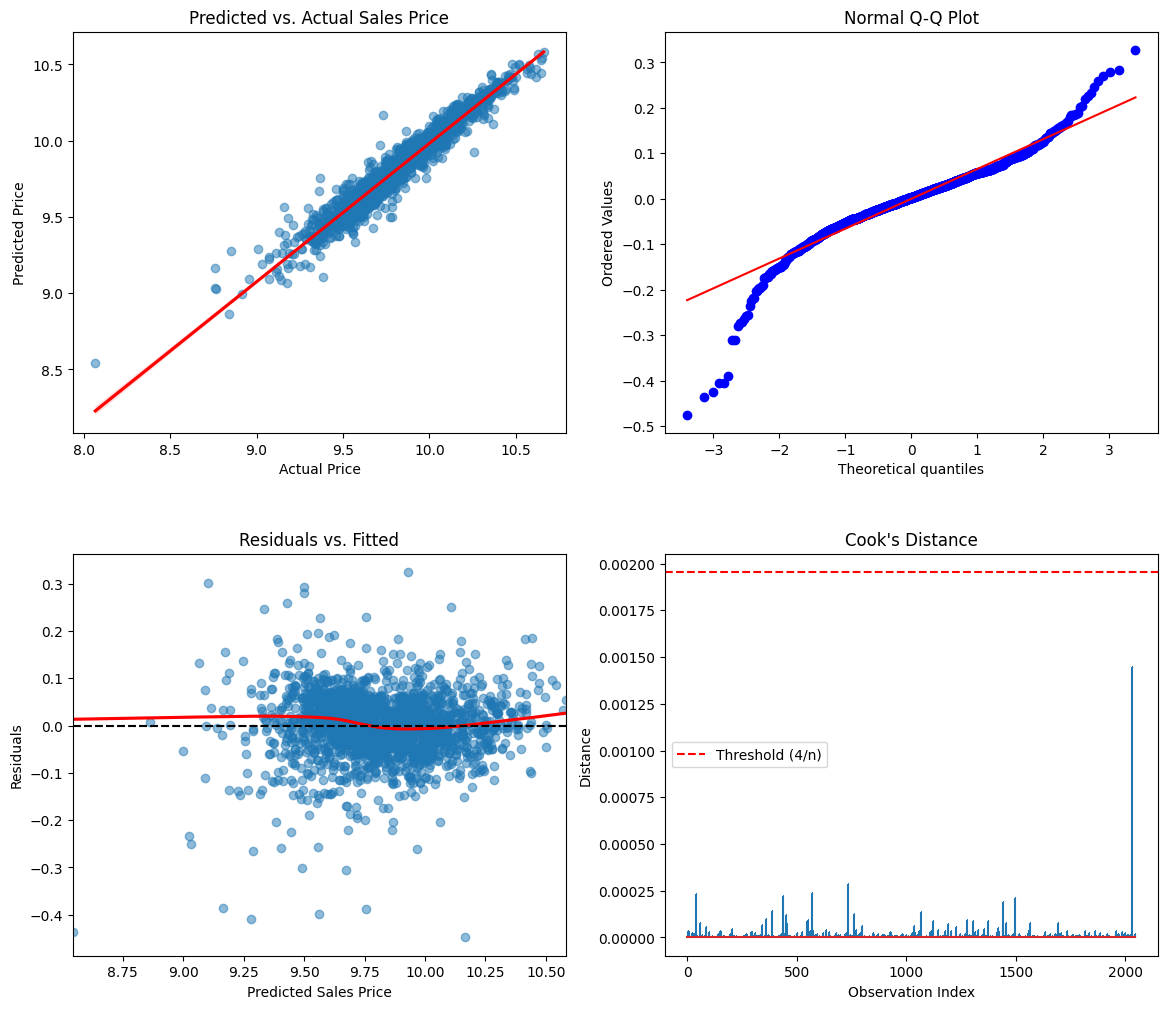

In [296]:
plot_regression_diagnostics(elastic_net3, y_train_boxcox, y_pred_boxcox, X_train_scaled)

log on y box cox on x

In [297]:
y_train_log = np.log1p(y_train)

In [298]:
X_train_trans = X_train.copy()

for col in pos_skew.index:
        log_transformer = FunctionTransformer(np.log1p, validate=True)
        X_train_trans[col] = log_transformer.transform(X_train_trans[[col]]).ravel()
        
for col in neg_skew.index:
        pt = PowerTransformer(method='yeo-johnson')
        X_train_trans[col] = pt.fit_transform(X_train_trans[[col]]).ravel()
        

In [299]:
X_train_scaled = scaler.fit_transform(X_train_trans)

In [300]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_train_log)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net4 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net4.fit(X_train_scaled, y_train_log)

Optimal Alpha: 0.040949150623804234
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.040949150623804234), l1_ratio=np.float64(0.1))

In [301]:
y_pred_log = elastic_net4.predict(X_train_scaled)
y_pred_org = np.expm1(y_pred_log)

model_diagnostics(elastic_net4, X_train_scaled, y_train, y_pred_org)

Model Diagnostics:
RMSE: 19746.2212
R²: 0.9394 | Adj R²: 0.9366
AIC: 40674.5971 | BIC: 41186.3930
Mallows' Cp: 20.4267
Parameters (p): 91


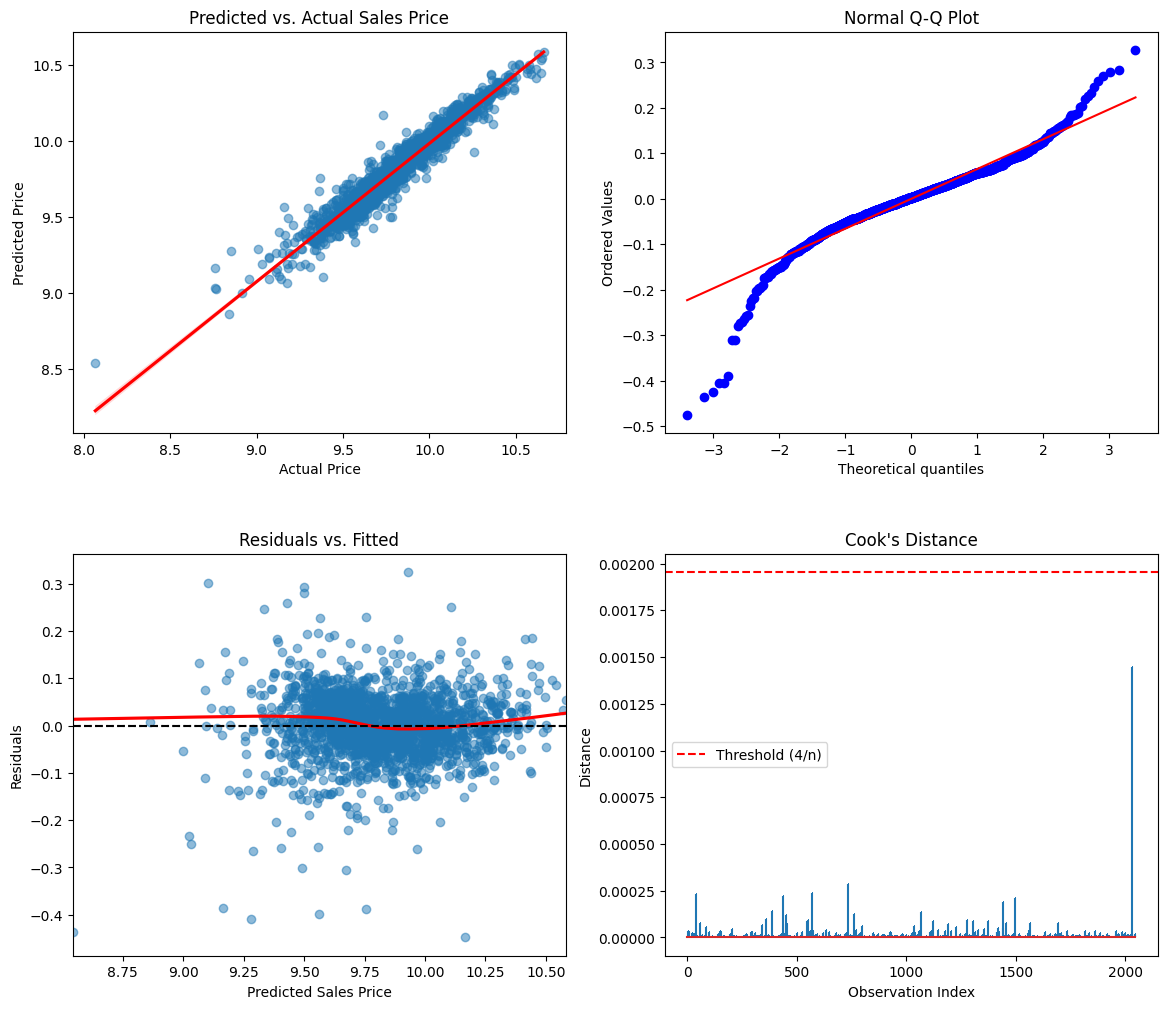

In [302]:
plot_regression_diagnostics(elastic_net4, y_train_boxcox, y_pred_boxcox, X_train_scaled)

we get the best result for elastic_net2

In [303]:
coefficients = elastic_net2.coef_
regressor = pd.Series(coefficients, index=X_train.columns)
print(regressor.sort_values(ascending=False).head(10))

GrLivArea      0.108437
OverallQual    0.080813
TotalBsmtSF    0.047780
YearBuilt      0.042284
LotArea        0.040241
OverallCond    0.037215
BsmtQual_Ex    0.021643
GarageCars     0.020106
Fireplaces     0.019881
GarageArea     0.019727
dtype: float64


In [304]:
selected_features = regressor[regressor != 0].index.tolist()
print(f"Features selected by Elastic Net: {len(selected_features)}")
print(selected_features)

Features selected by Elastic Net: 93
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'ScreenPorch', 'PoolArea', 'YrSold', 'MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RM', 'LandContour_HLS', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LandSlope_Mod', 'Neighborhood_BrkSide', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Condition1_Norm', 'Condition1_PosN', 'Condition2_Feedr', 'Condition2_PosA', 'BldgType_Duplex', 'BldgType_Twnhs', 'HouseStyle_1.5Unf', 'RoofStyle_Gambrel', 'RoofStyle_Hip', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShngl', 'Exterior1st_BrkComm', 'Exterior1st_BrkFace', 'Exterior2nd_CBlock', 'Exterior2

In [305]:
""" X_train_selected = X_train[selected_features]
X_train_selected = X_train_selected.astype(float)
full_model = sm.OLS(y_train, sm.add_constant(X_train_selected)).fit()
mse_full_model = full_model.mse_resid
print(f"Full Model MSE: {mse_full_model:.4f}") """

' X_train_selected = X_train[selected_features]\nX_train_selected = X_train_selected.astype(float)\nfull_model = sm.OLS(y_train, sm.add_constant(X_train_selected)).fit()\nmse_full_model = full_model.mse_resid\nprint(f"Full Model MSE: {mse_full_model:.4f}") '

In [306]:
def stepwise_selection(X, y, initial_list=[], threshold_in=0.01, threshold_out=0.05):
    X = X.astype(float)
    y = y.astype(float)
    
    included = list(initial_list)
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        
        for new_col in excluded:
            current_X = sm.add_constant(X[included + [new_col]])
            model = sm.OLS(y, current_X).fit()
            new_pval[new_col] = model.pvalues[new_col]
        
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            print(f'Add  {best_feature:30} with p-value {best_pval:.6f}')

        if included:
            current_X = sm.add_constant(X[included])
            model = sm.OLS(y, current_X).fit()
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max() 
            if worst_pval > threshold_out:
                changed = True
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                print(f'Drop {worst_feature:30} with p-value {worst_pval:.6f}')
        
        if not changed:
            break
    return included


In [307]:
selected_features = regressor[regressor != 0].index.tolist()
final_features = stepwise_selection(X_train[selected_features], y_train)

print("\nFinal Selected Features:", final_features)

Add  OverallQual                    with p-value 0.000000
Add  GrLivArea                      with p-value 0.000000
Add  TotalBsmtSF                    with p-value 0.000000
Add  BsmtQual_Ex                    with p-value 0.000000
Add  YearBuilt                      with p-value 0.000000
Add  LotArea                        with p-value 0.000000
Add  OverallCond                    with p-value 0.000000
Add  BsmtExposure_Gd                with p-value 0.000000
Add  GarageArea                     with p-value 0.000000
Add  KitchenAbvGr                   with p-value 0.000000
Add  Neighborhood_NoRidge           with p-value 0.000000
Add  Neighborhood_NridgHt           with p-value 0.000000
Add  Neighborhood_StoneBr           with p-value 0.000000
Add  Neighborhood_Crawfor           with p-value 0.000000
Add  BsmtFullBath                   with p-value 0.000000
Add  SaleType_New                   with p-value 0.000000
Add  Condition2_PosA                with p-value 0.000000
Add  BldgType_

In [308]:
print(f"Final number of features after stepwise selection: {len(final_features)}")  

Final number of features after stepwise selection: 44


In [309]:
X_final = X_train[final_features].astype(float)
X_test_final = X_test[final_features].astype(float)

X_final_with_const = sm.add_constant(X_final)
y_final = y_train.astype(float)

final_ols_model = sm.OLS(y_final, X_final_with_const).fit()
print(final_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     504.8
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:17:27   Log-Likelihood:                -23469.
No. Observations:                2047   AIC:                         4.703e+04
Df Residuals:                    2002   BIC:                         4.728e+04
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -5.769e+05 

In [310]:
def model_diagno_ols(y, y_pred, k_features): 
    
    
    rmse_final = np.sqrt(mean_squared_error(y, y_pred))
    rss = np.sum((y - y_pred) ** 2)
    r2 = r2_score(y, y_pred) 
    
    p_params = k_features + 1  # Number of features + 1 for the intercept
    n = len(y)
    
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p_params)
    
    AIC = n * np.log(rss / n) + 2 * p_params
    BIC = n * np.log(rss / n) + p_params * np.log(n)
    CP = rss / mse_full_model - (n - 2 * p_params)
    print(f"Final Model Diagnostics:")
    print(f"RMSE: {rmse_final:.4f}")
    print(f"R²: {r2:.4f} | Adj R²: {adj_r2:.4f}")
    print(f"AIC: {AIC:.4f} | BIC: {BIC:.4f}")
    print(f"RSS: {rss:.4f} | Parameters (p): {p_params}")
    print(f"Mallows' Cp: {CP:.4f}")

In [311]:
def model_diagno_plot_ols(model, y, y_pred):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    sns.scatterplot(x=y, y=y_pred, ax=axes[0, 0], alpha=0.6)
    axes[0, 0].plot([y.min(), y.max()], 
                    [y.min(), y.max()], 
                    'r--', lw=2)
    
    axes[0, 0].set_title('Actual vs. Predicted')
    axes[0, 0].set_xlabel('Actual Values')
    axes[0, 0].set_ylabel('Predicted Values')

    residuals = y - y_pred
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 1], alpha=0.6)
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_title('Residuals vs. Fitted')
    axes[0, 1].set_xlabel('Fitted Values')
    axes[0, 1].set_ylabel('Residuals')

    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Normal Q-Q Plot')

    influence_obj = model.get_influence()
    (c_dist, p_val) = influence_obj.cooks_distance 

    axes[1, 1].stem(np.arange(len(c_dist)), c_dist, markerfmt=",")
    axes[1, 1].set_title("Cook's Distance")
    axes[1, 1].set_xlabel('Observation Index')
    axes[1, 1].set_ylabel('Distance')
    threshold = 4 / len(y) 
    axes[1, 1].axhline(y=threshold, color='r', linestyle='--', label='4/n threshold')

In [312]:
y_pred = final_ols_model.predict(X_final_with_const)
model_diagno_ols(y_final, y_pred, len(final_features))

Final Model Diagnostics:
RMSE: 23062.3471
R²: 0.9173 | Adj R²: 0.9155
AIC: 41218.1462 | BIC: 41471.2321
RSS: 1088741681669.4900 | Parameters (p): 45
Mallows' Cp: 614.8679


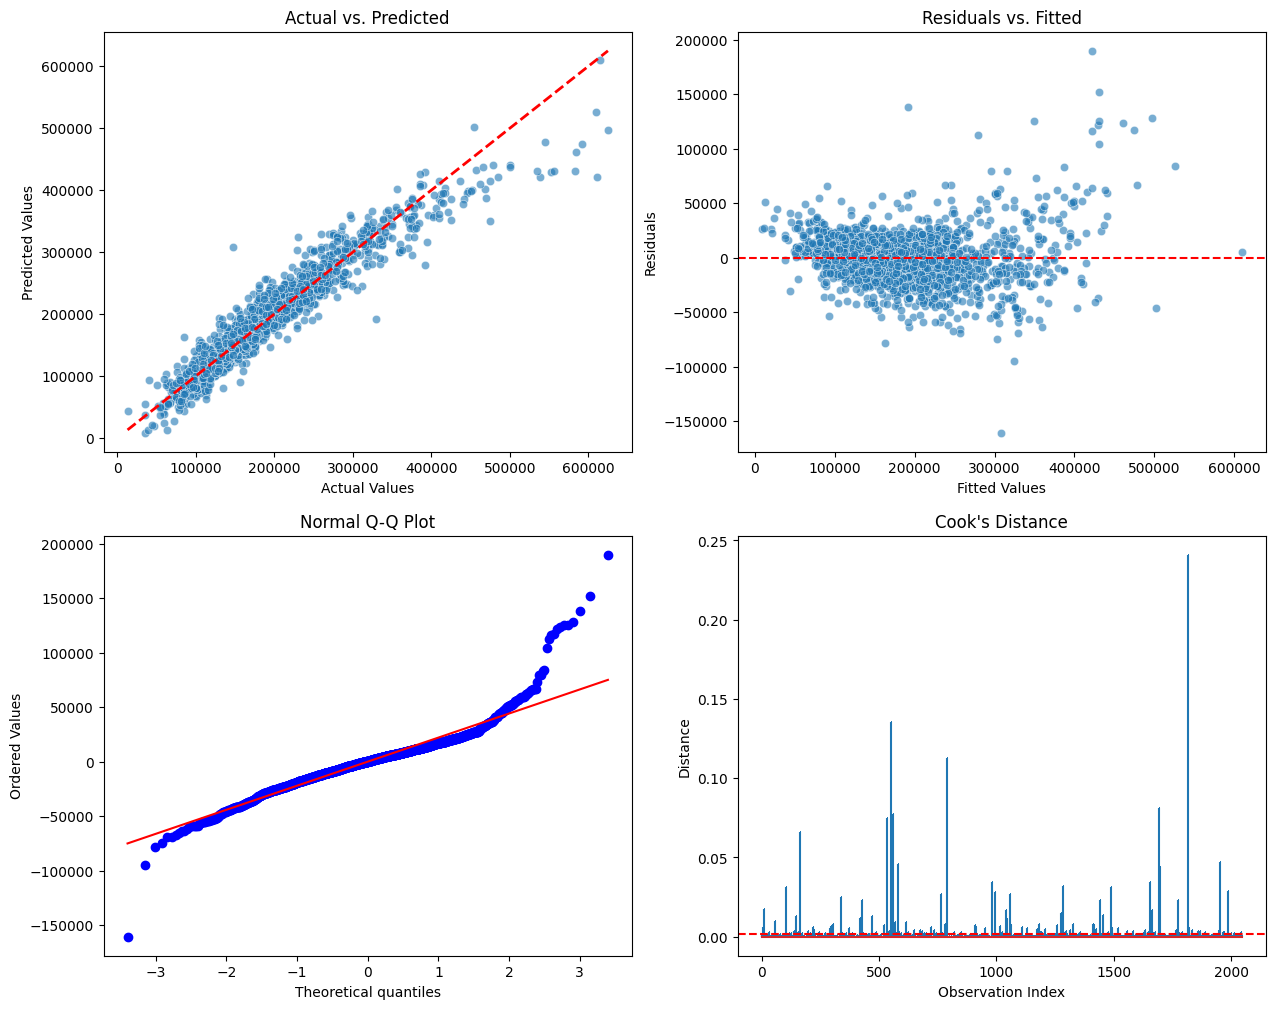

In [313]:
model_diagno_plot_ols(final_ols_model, y_final, final_ols_model.fittedvalues)

In [314]:
y_final_transformed = np.log1p(y_final)

pos_skew = X_final.skew()[X_final.skew() > 0.5]
neg_skew = X_final.skew()[X_final.skew() < -0.5]

In [315]:
X_train_trans_final = X_final.copy()
X_test_final_trans = X_test_final.copy()

for col in pos_skew.index:
        log_transformer = FunctionTransformer(np.log1p, validate=True)
        X_train_trans_final[col] = log_transformer.transform(X_train_trans_final[[col]]).ravel()
        
        X_test_final_trans[col] = log_transformer.transform(X_test_final_trans[[col]]).ravel()
for col in neg_skew.index:
        pt = PowerTransformer(method='yeo-johnson')
        X_train_trans_final[col] = pt.fit_transform(X_train_trans_final[[col]]).ravel()
        
        X_test_final_trans[col] = pt.transform(X_test_final_trans[[col]]).ravel()

In [316]:
X_train_trans_final = X_train_trans_final.astype(float)
X_final_with_const = sm.add_constant(X_train_trans_final)


final_ols_model = sm.OLS(y_final_transformed, X_final_with_const).fit()
print(final_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     589.5
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:17:28   Log-Likelihood:                 1641.0
No. Observations:                2047   AIC:                            -3192.
Df Residuals:                    2002   BIC:                            -2939.
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6093 

analysis on transformed data

In [317]:
y_pred = final_ols_model.predict(X_final_with_const)

In [318]:
model_diagno_ols(y_final_transformed, y_pred, k_features=len(final_features))

Final Model Diagnostics:
RMSE: 0.1085
R²: 0.9283 | Adj R²: 0.9268
AIC: -9001.1095 | BIC: -8748.0237
RSS: 24.1176 | Parameters (p): 45
Mallows' Cp: -1957.0000


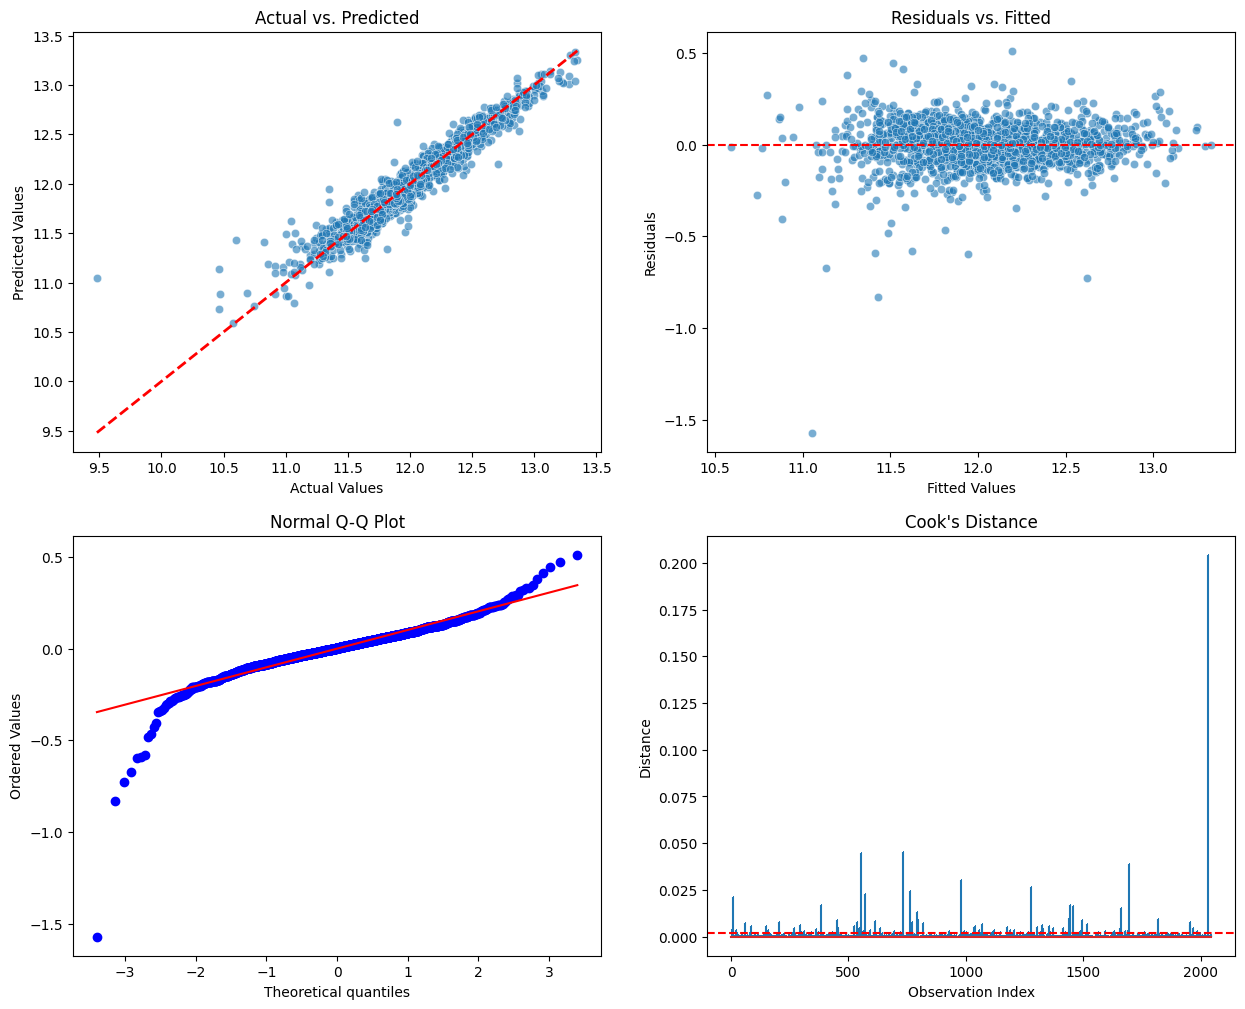

In [319]:
model_diagno_plot_ols(final_ols_model, y_final_transformed, y_pred)

analysis on original scale

In [320]:
model_diagno_ols(y_train, y_pred_org, k_features=len(final_features))

Final Model Diagnostics:
RMSE: 19746.2212
R²: 0.9394 | Adj R²: 0.9381
AIC: 40582.5971 | BIC: 40835.6830
RSS: 798152427655.3323 | Parameters (p): 45
Mallows' Cp: -71.5733


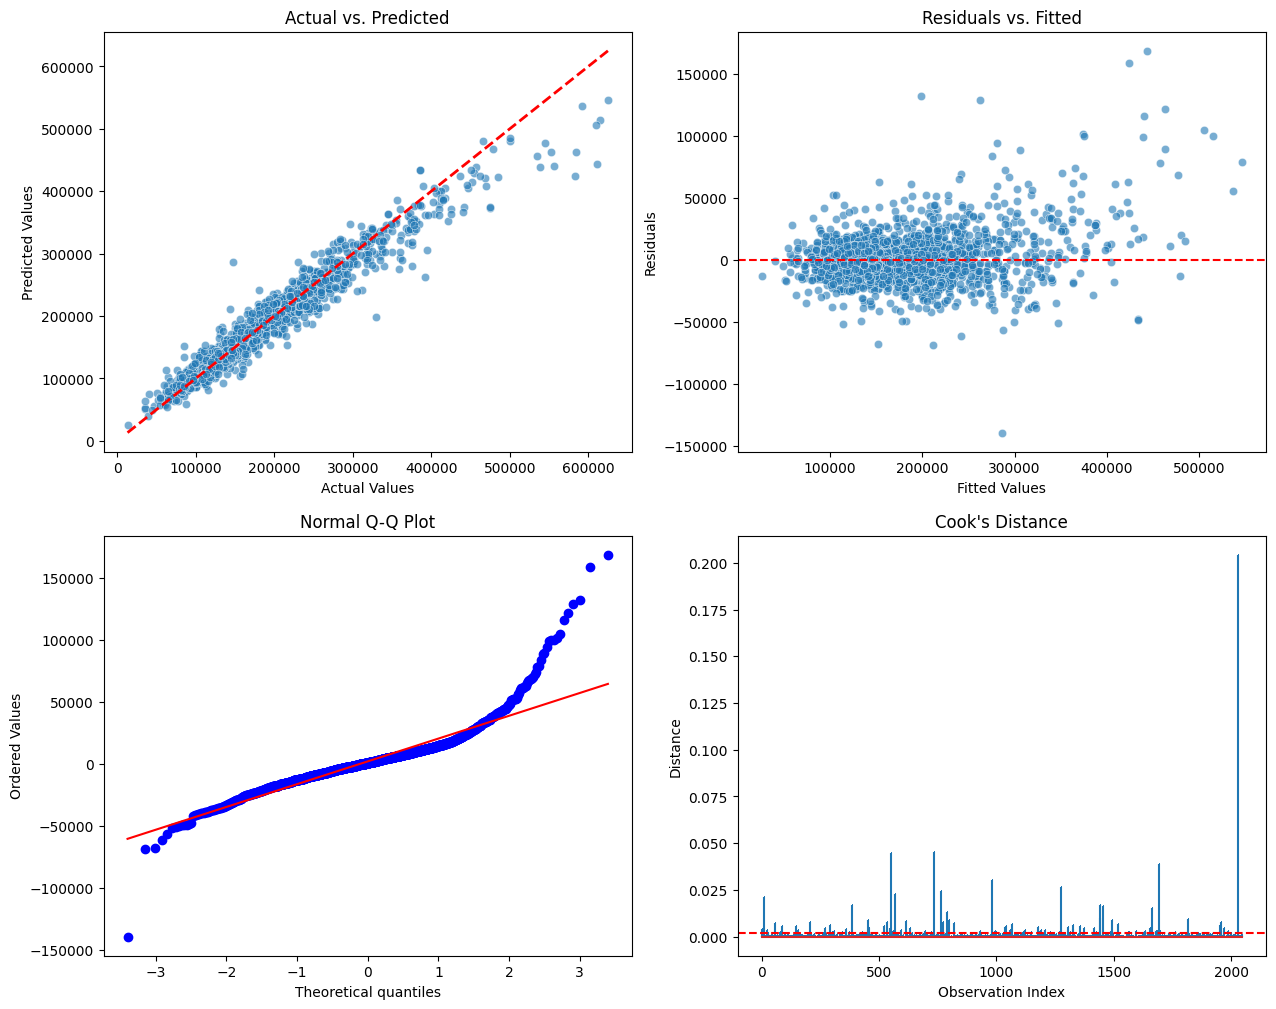

In [321]:
model_diagno_plot_ols(final_ols_model, y_train, y_pred_org)

on test data

In [322]:
X_test_final_trans = X_test_final_trans.astype(float)
y_test_final = y_test.astype(float)
y_test_final_transformed = np.log1p(y_test_final)

X_with_const_test = sm.add_constant(X_test_final_trans)
y_pred_test = final_ols_model.predict(X_with_const_test)
y_pred_test_org = np.expm1(y_pred_test)

analysis on transform data

In [323]:
model_diagno_ols(y_test_final_transformed, y_pred_test, k_features=len(final_features))

Final Model Diagnostics:
RMSE: 0.1242
R²: 0.9069 | Adj R²: 0.9020
AIC: -3573.4592 | BIC: -3358.4651
RSS: 13.5331 | Parameters (p): 45
Mallows' Cp: -788.0000


analysis on original scale

In [324]:
model_diagno_ols(y_test_final, y_pred_test_org, k_features=len(final_features))

Final Model Diagnostics:
RMSE: 20468.1294
R²: 0.9245 | Adj R²: 0.9205
AIC: 17521.1523 | BIC: 17736.1464
RSS: 367833112881.2731 | Parameters (p): 45
Mallows' Cp: 80.9097


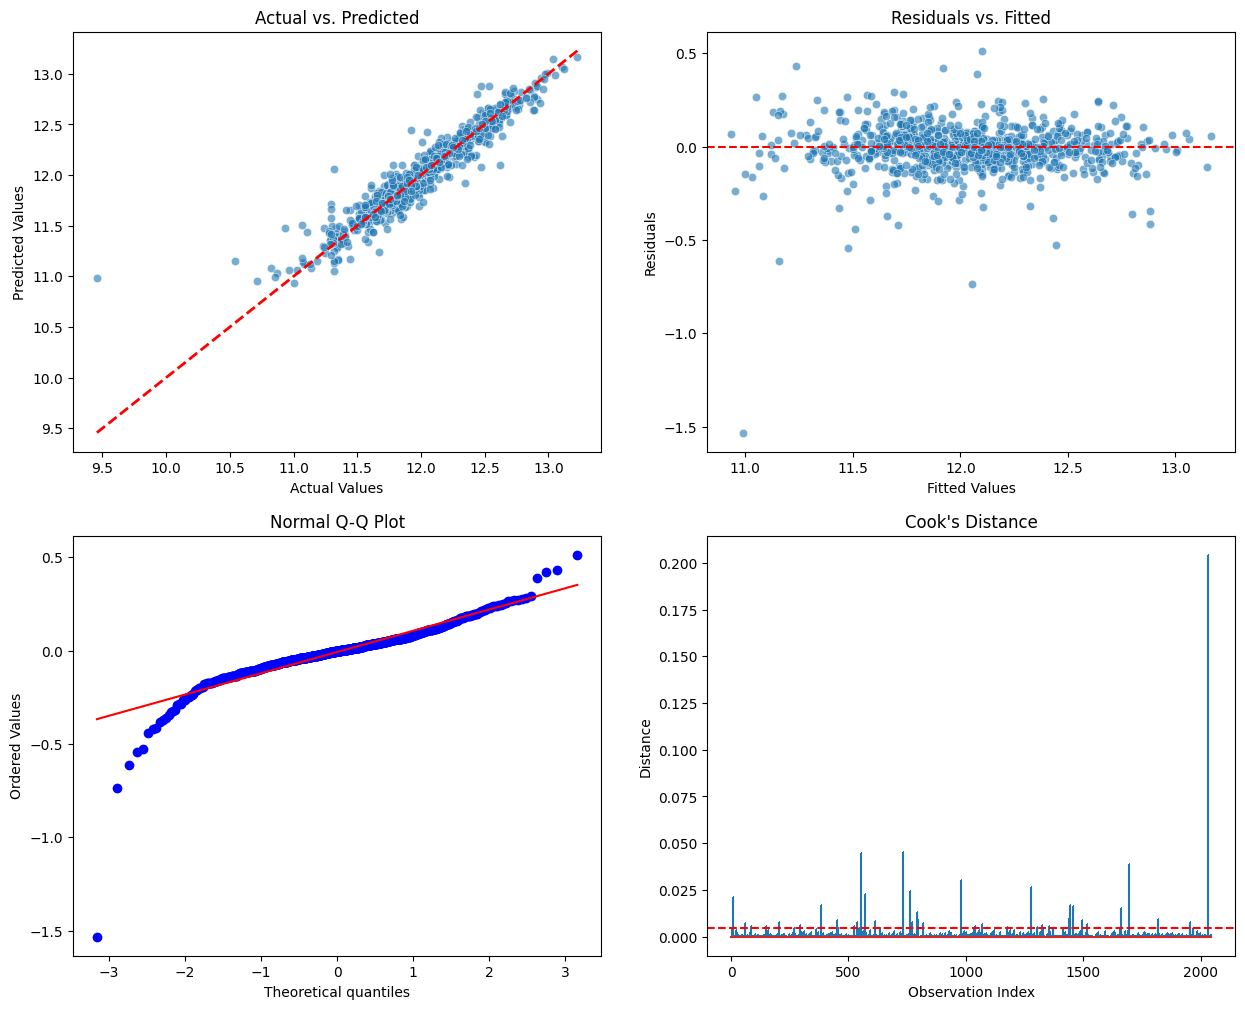

In [325]:
model_diagno_plot_ols(final_ols_model, y_test_final_transformed, y_pred_test)

analysis on residuals and error 

In [326]:
ols_model = sm.OLS(y_final, sm.add_constant(X_final)).fit()

In [327]:
c_dist, p_val = ols_model.get_influence().cooks_distance
threshold = 4 / len(y_train)
cooks_df = pd.DataFrame({'distance': c_dist}, index=X_final.index)

influential_points = cooks_df[cooks_df['distance'] 
                              > threshold].sort_values(by='distance', ascending=False)

print(f"Number of influential points: {len(influential_points)}")
print(influential_points.head(10)) 

print(X_final.loc[influential_points.index[0]])

Number of influential points: 139
      distance
432   0.240960
2666  0.135296
1063  0.112771
2089  0.081241
1637  0.077381
1642  0.074817
1570  0.066243
2766  0.047061
2275  0.045699
15    0.043630
OverallQual                10.0
GrLivArea                2674.0
TotalBsmtSF              2630.0
BsmtQual_Ex                 1.0
YearBuilt                2007.0
LotArea                 13693.0
OverallCond                 5.0
BsmtExposure_Gd             1.0
GarageArea                762.0
KitchenAbvGr                1.0
Neighborhood_NoRidge        0.0
Neighborhood_NridgHt        1.0
Neighborhood_StoneBr        0.0
Neighborhood_Crawfor        0.0
BsmtFullBath                2.0
SaleType_New                0.0
Condition2_PosA             1.0
BldgType_Twnhs              0.0
ScreenPorch                 0.0
Neighborhood_Somerst        0.0
BsmtFinType1_Unf            0.0
ExterQual_TA                0.0
Functional_Typ              1.0
Fireplaces                  2.0
PoolQC_NA                   1.0
E

residuals analysis

In [328]:
influence = ols_model.get_influence()

standardized_residuals = influence.resid_studentized_internal
studentized_residuals = influence.resid_studentized_external

In [329]:
df_diag = df_cleaned2.copy()
df_diag = df_diag.iloc[:len(y_train)]
df_diag['Actual'] = y_train
df_diag['Predicted'] = y_pred_original
df_diag['Stand_Resid'] = standardized_residuals
df_diag['Stud_Resid'] = studentized_residuals

df_diag['Residual'] = df_diag['SalePrice'] - df_diag['Predicted']
extreme_outliers_neg = df_diag[df_diag['Stud_Resid'] < -3]
print(f"Found {len(extreme_outliers_neg)} significant negative outliers.")
print(extreme_outliers_neg[['SalePrice', 'Predicted', 'GrLivArea', 'Residual', 'Stud_Resid', 'Stand_Resid']])

Found 6 significant negative outliers.
      SalePrice      Predicted  GrLivArea       Residual  Stud_Resid  \
165    160000.0  260247.132497     1116.0 -100247.132497   -3.555797   
306     55993.0  222782.364675     1044.0 -166789.364675   -3.013116   
570    172500.0  151596.706743     1471.0   20903.293257   -3.429314   
763    179000.0  286219.958540     1200.0 -107219.958540   -7.057035   
911    135000.0  303066.423771     1981.0 -168066.423771   -3.026351   
1041   100500.0  288327.216373      987.0 -187827.216373   -4.161258   

      Stand_Resid  
165     -3.545502  
306     -3.007054  
570     -3.420135  
763     -6.972564  
911     -3.020203  
1041    -4.144404  


In [330]:
df_diag = df_cleaned2.copy()
df_diag = df_diag.iloc[:len(y_train)]
df_diag['Actual'] = y_train
df_diag['Predicted'] = y_pred_original
df_diag['Stand_Resid'] = standardized_residuals
df_diag['Stud_Resid'] = studentized_residuals

df_diag['Residual'] = df_diag['SalePrice'] - df_diag['Predicted']
extreme_outliers_neg = df_diag[df_diag['Stud_Resid'] < -3]
extreme_outliers_pos = df_diag[df_diag['Stud_Resid'] > 3]
print(f"Found {len(extreme_outliers_pos)} significant positive outliers.")
print(extreme_outliers_pos[['SalePrice', 'Predicted', 'GrLivArea', 'Residual', 'Stud_Resid', 'Stand_Resid']])

Found 18 significant positive outliers.
      SalePrice      Predicted  GrLivArea       Residual  Stud_Resid  \
59     333168.0  197426.980672     2599.0  135741.019328    6.036941   
148    108000.0  280026.180191     1337.0 -172026.180191    3.489599   
337    136000.0  363357.295681     1274.0 -227357.295681    5.510547   
417    128500.0  407097.247658      836.0 -278597.247658    3.639343   
428    335000.0  456254.644087     2184.0 -121254.644087    5.367748   
553     76000.0  372507.760376      784.0 -296507.760376    3.237744   
560    131400.0  527180.093233     1144.0 -395780.093233    5.345125   
720     58500.0  304445.096930      816.0 -245945.096930    3.440918   
1016   215000.0  361838.634961     2093.0 -146838.634961    3.190204   
1057   383000.0  422110.979821     1950.0  -39110.979821    6.700860   
1285   157500.0  544319.376246     1539.0 -386819.376246    5.665344   
1441   231500.0  262149.967614     1792.0  -30649.967614    4.961217   
1486   145900.0  459942.

analysis without extremme obs

In [331]:
outlier_index = extreme_outliers_neg.index.union(extreme_outliers_pos.index)

valid_index = X_final.index.intersection(outlier_index)

X_final_no_outliers = X_final.drop(index=valid_index)
y_final_no_outliers = y_final.drop(index=valid_index)

In [332]:
print(f"Removed {len(valid_index)} outliers from the training set.")

Removed 16 outliers from the training set.


In [333]:
print(X_final_no_outliers.head())

      OverallQual  GrLivArea  TotalBsmtSF  BsmtQual_Ex  YearBuilt  LotArea  \
1936          5.0     1360.0        384.0          0.0     1955.0   7134.0   
2761          7.0     1614.0       1614.0          0.0     2005.0   9316.0   
1725          8.0     1324.0       1324.0          0.0     2006.0   6240.0   
1328          7.0     1668.0        672.0          0.0     1945.0   7425.0   
1757          7.0     1320.0        660.0          0.0     2003.0   7750.0   

      OverallCond  BsmtExposure_Gd  GarageArea  KitchenAbvGr  ...  \
1936          5.0              0.0       572.0           1.0  ...   
2761          5.0              1.0       576.0           1.0  ...   
1725          5.0              0.0       550.0           1.0  ...   
1328          7.0              0.0       252.0           1.0  ...   
1757          5.0              0.0       400.0           1.0  ...   

      LotFrontage  RoofMatl_Tar&Grv  Exterior2nd_CmentBd  BsmtFinType1_Rec  \
1936         60.0               0.0   

In [334]:
exclude_outliers_model = sm.OLS(y_final_no_outliers, sm.add_constant(X_final_no_outliers)).fit()
print(exclude_outliers_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     498.3
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:18:03   Log-Likelihood:                -23291.
No. Observations:                2031   AIC:                         4.667e+04
Df Residuals:                    1986   BIC:                         4.692e+04
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -5.756e+05 

Final Model Diagnostics:
RMSE: 23127.8933
R²: 0.9169 | Adj R²: 0.9151
AIC: 40908.2040 | BIC: 41160.9367
RSS: 1086380782832.2493 | Parameters (p): 45
Mallows' Cp: 625.2909


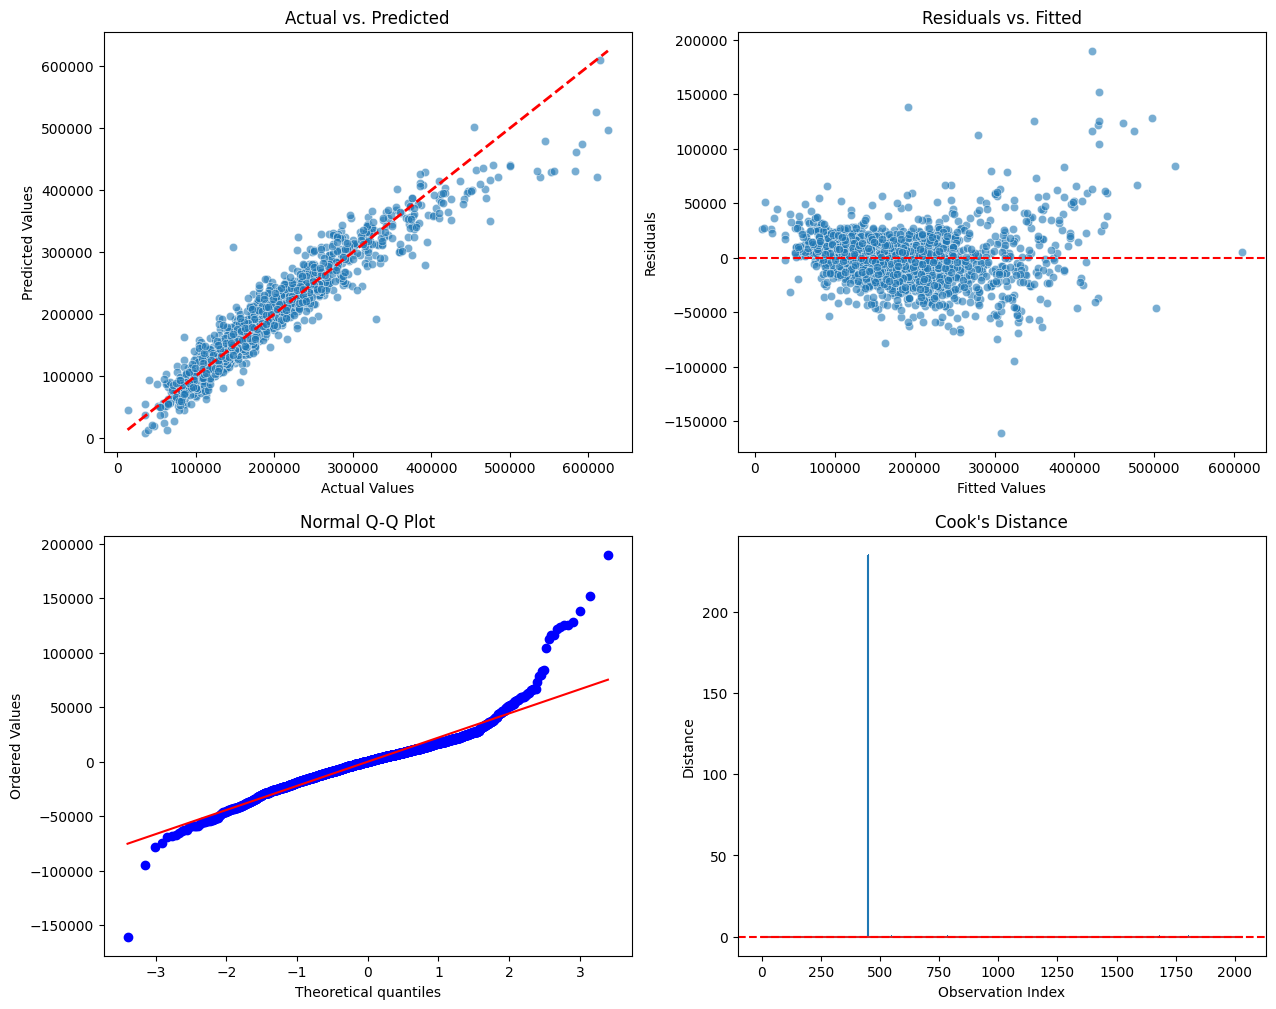

In [335]:
y_final_no_out_pred = exclude_outliers_model.predict(sm.add_constant(X_final_no_outliers))

model_diagno_ols(y_final_no_outliers, y_final_no_out_pred, k_features=len(final_features))
model_diagno_plot_ols(exclude_outliers_model, y_final_no_outliers, y_final_no_out_pred)

In [336]:
ex_out_pred_test = exclude_outliers_model.predict(sm.add_constant(X_test_final))

Final Model Diagnostics:
RMSE: 24750.8905
R²: 0.8896 | Adj R²: 0.8838
AIC: 17854.7790 | BIC: 18069.7731
RSS: 537868576557.3753 | Parameters (p): 45
Mallows' Cp: 482.5741


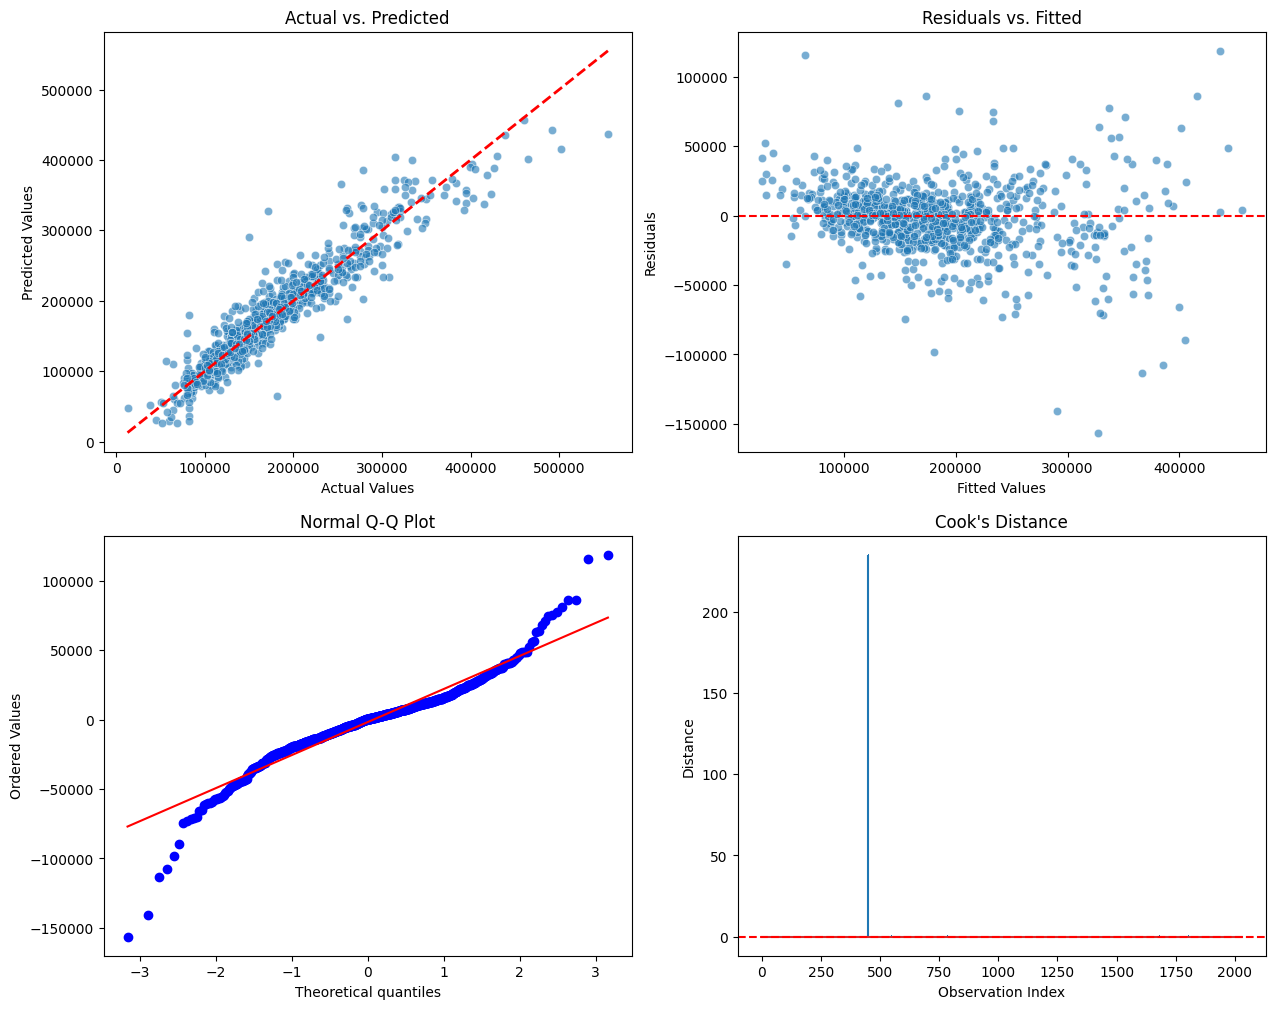

In [337]:
model_diagno_ols(y_test_final, ex_out_pred_test, k_features=len(final_features))
model_diagno_plot_ols(exclude_outliers_model, y_test_final, ex_out_pred_test)

without influencial obs

In [338]:
influential_index = influential_points.index
common_index = X_final.index.intersection(influential_index)
x_train_without_influential = X_final.drop(common_index, axis=0)
y_train_without_influential = y_final.drop(common_index, axis=0)

In [339]:
ols_no_influential = sm.OLS(y_train_without_influential, 
                            sm.add_constant(x_train_without_influential)).fit()

In [340]:
print(ols_no_influential.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     781.6
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:18:05   Log-Likelihood:                -21154.
No. Observations:                1908   AIC:                         4.239e+04
Df Residuals:                    1867   BIC:                         4.262e+04
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -4.237e+05 

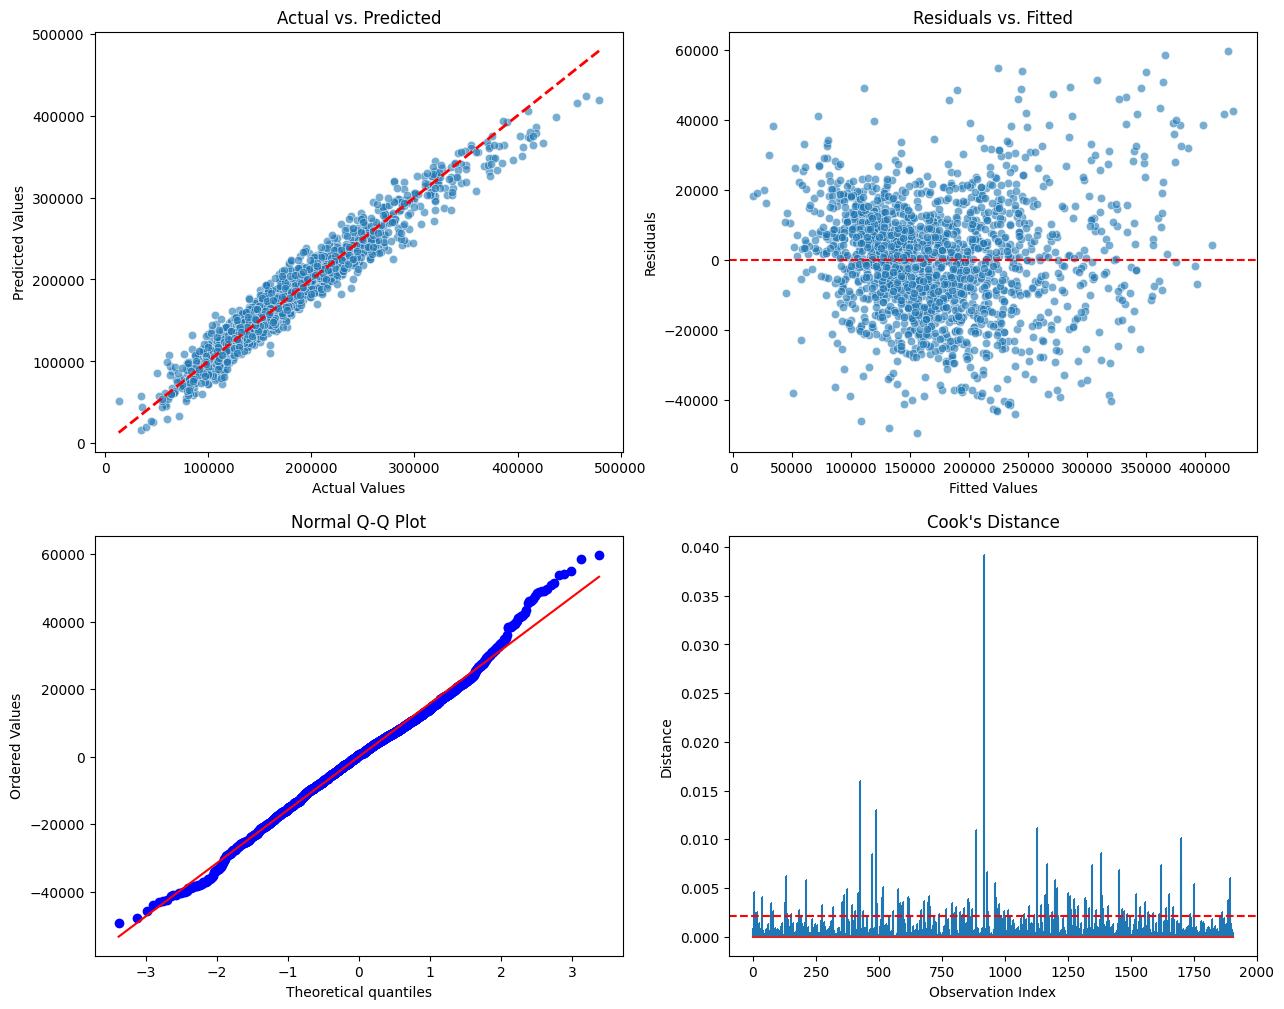

In [341]:
model_diagno_plot_ols(ols_no_influential, y_train_without_influential, 
                      ols_no_influential.predict(sm.add_constant(x_train_without_influential)))

In [342]:
model_diagno_ols(y_test_final, 
                 ols_no_influential.predict(sm.add_constant(X_test_final)), 
                 k_features=len(final_features))

Final Model Diagnostics:
RMSE: 27400.9242
R²: 0.8647 | Adj R²: 0.8576
AIC: 18033.3910 | BIC: 18248.3851
RSS: 659211750364.9006 | Parameters (p): 45
Mallows' Cp: 769.2156


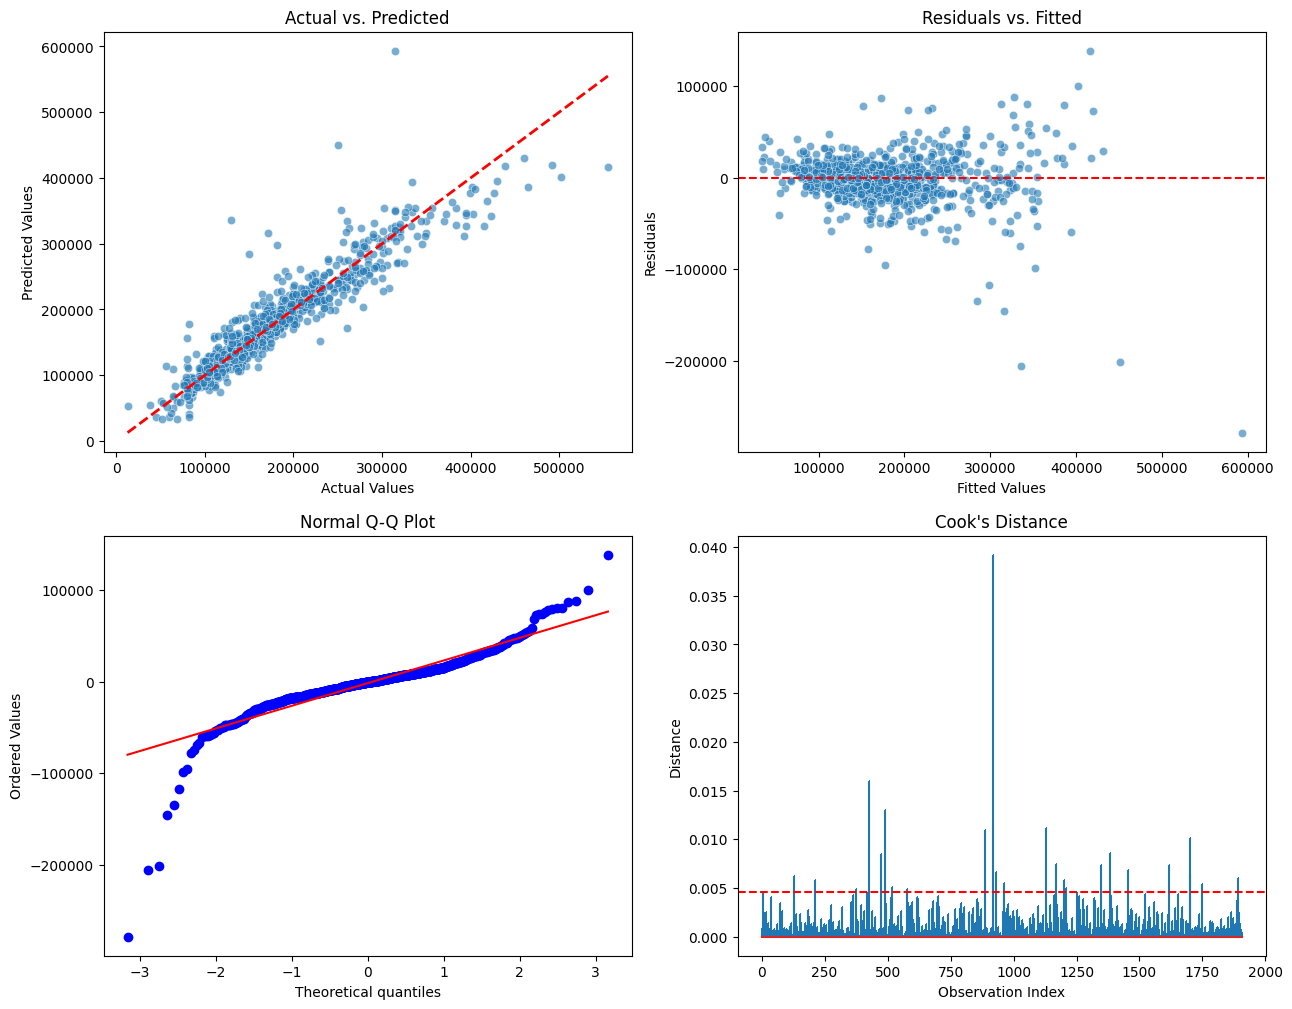

In [343]:
model_diagno_plot_ols(ols_no_influential, 
                      y_test_final, 
                      ols_no_influential.predict(sm.add_constant(X_test_final)))